In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import glob
import os
from matplotlib.ticker import ScalarFormatter

In [17]:
model_outputs = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/2025-02-19/"

# Check the specific pattern
run_summary_files = glob.glob(os.path.join(model_outputs, "*", "*run_summary.csv"))
 
# Read in the run summary files
run_summary = pd.concat([pd.read_csv(f) for f in run_summary_files])

# Split into K=2 and K=9 since seperate types of analysis
run_summary_K2 = run_summary[run_summary["K"] == 2]
run_summary_K9 = run_summary[run_summary["K"] == 9]

# Let's have another calumn likelihood if input_conc is a number then beta-binom and if "inf" then binomial
run_summary_K2["likelihood"] = np.where(run_summary_K2["input_conc"] == np.inf, "binomial", "beta-binomial")
run_summary_K9["likelihood"] = np.where(run_summary_K9["input_conc"] == np.inf, "binomial", "beta-binomial")

/scratch/ipykernel_3774335/1891020702.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  run_summary_K2["likelihood"] = np.where(run_summary_K2["input_conc"] == np.inf, "binomial", "beta-binomial")
/scratch/ipykernel_3774335/1891020702.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  run_summary_K9["likelihood"] = np.where(run_summary_K9["input_conc"] == np.inf, "binomial", "beta-binomial")


In [18]:
# find *classification_metrics.csv files and read them in while adding in which "run_X" subfolder they came from
classification_metrics_files = glob.glob(os.path.join(model_outputs, "*", "*classification_metrics.csv"))
# Read in the classification metrics files and add in the run number
classification_metrics = pd.concat([pd.read_csv(f).assign(run=f.split("/")[11]) for f in classification_metrics_files])
# make param_id column of just the run number "run_x"
classification_metrics["param_id"] = classification_metrics["run"].str.split("_").str[1]
# Make param_id an integer64
classification_metrics["param_id"] = classification_metrics["param_id"].astype("int64")
run_summary_K2 = run_summary_K2.merge(classification_metrics, on="param_id")

### Compare model performance (which has the lowest -ELBO values...) across different configurations of parameters

In [27]:
run_summary_K2

,param_id,K,junc_specific_prior,best_elbo,input_conc,num_epochs,num_inits,cell_type_silhouette,avg_corr,median_corr,min_corr,lr,ELBO_num_particles,num_samples,proportion_negative,pruned_K,likelihood,auc_pr,auc_roc,run
0,26,2,False,2.785181e+07,1660.285200,300,5,0.930445,0.929524,0.908810,0.891891,0.8,10,500,0.85,2,beta-binomial,0.959860,0.953768,run_26
1,3,2,True,2.816058e+07,3307.481400,300,5,0.959732,0.996106,0.997262,0.992982,0.5,10,500,0.50,2,beta-binomial,0.975413,0.961824,run_3
2,23,2,False,2.703537e+07,3646.593500,300,5,0.945056,0.598753,0.998929,-0.020178,0.5,10,500,0.85,2,beta-binomial,0.566983,0.500000,run_23
3,2,2,True,3.265411e+07,75.710060,300,5,0.925959,0.786046,0.946362,0.459550,0.1,10,500,0.85,2,beta-binomial,0.812949,0.927302,run_2
4,57,2,False,2.776624e+07,inf,300,5,0.959438,0.991020,0.996391,0.978644,0.5,10,500,0.50,2,binomial,0.976136,0.962358,run_57
5,38,2,True,1.572756e+08,inf,300,5,0.808231,0.420170,0.414098,0.065374,0.1,10,500,0.85,2,binomial,0.331537,0.608371,run_38
6,19,2,False,2.873011e+07,1038.908000,300,5,0.969982,0.389366,0.081899,0.012699,0.1,10,500,0.15,2,beta-binomial,0.984393,0.936313,run_19
7,60,2,False,2.744205e+07,inf,300,5,0.965130,0.239601,0.075836,-0.018102,0.8,10,500,0.50,2,binomial,0.579911,0.633263,run_60
8,41,2,True,3.626807e+07,inf,300,5,0.885932,0.962430,0.983318,0.919441,0.5,10,500,0.85,2,binomial,0.968626,0.972373,run_41
9,22,2,False,2.835002e+07,4471.543000,300,5,0.972263,0.998756,0.999180,0.997108,0.5,10,500,0.15,2,beta-binomial,0.985821,0.940265,run_22


Text(0.5, 1.05, 'Model Performance for K=2')

<Figure size 1200x600 with 0 Axes>

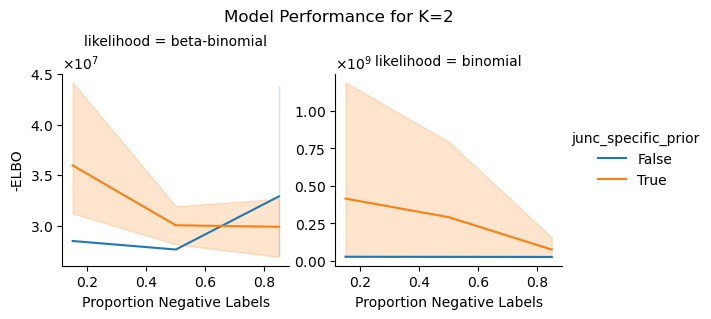

In [19]:
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(run_summary_K2, 
                  col="likelihood",
                  hue="junc_specific_prior",
                  sharey=False)

# Use line plot to show trends more clearly
g.map(sns.lineplot, "proportion_negative", "best_elbo")

# Format y-axis labels
for ax in g.axes.flat:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

g.add_legend()
g.set_axis_labels("Proportion Negative Labels", "-ELBO")

g.fig.suptitle('Model Performance for K=2', y=1.05)  # y=1.02 raises it slightly above the plots

Text(0.5, 1.05, 'Model Performance for K=2')

<Figure size 1200x600 with 0 Axes>

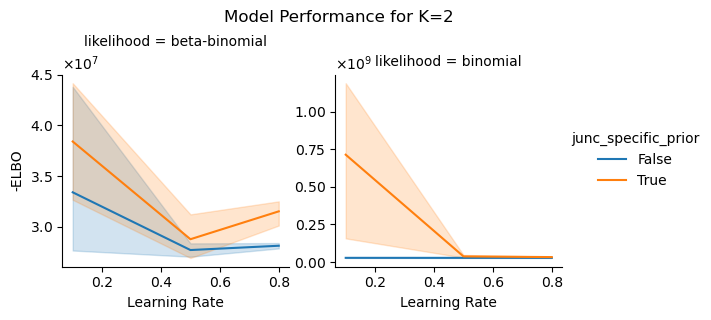

In [20]:
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(run_summary_K2, 
                  col="likelihood",
                  hue="junc_specific_prior",
                  sharey=False)

# Use line plot to show trends more clearly
g.map(sns.lineplot, "lr", "best_elbo")

# Format y-axis labels
for ax in g.axes.flat:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

g.add_legend()
g.set_axis_labels("Learning Rate", "-ELBO")

# Add title
g.fig.suptitle('Model Performance for K=2', y=1.05)  # y=1.02 raises it slightly above the plots

In [21]:
run_summary_K2[run_summary_K2["likelihood"] == "binomial"].sort_values(by=["junc_specific_prior", "best_elbo"])


,param_id,K,junc_specific_prior,best_elbo,input_conc,num_epochs,num_inits,cell_type_silhouette,avg_corr,median_corr,min_corr,lr,ELBO_num_particles,num_samples,proportion_negative,pruned_K,likelihood,auc_pr,auc_roc,run
27,59,2,False,2.690236e+07,inf,300,5,0.942094,0.350013,0.063822,-0.000844,0.5,10,500,0.85,2,binomial,0.971362,0.971011,run_59
10,56,2,False,2.695192e+07,inf,300,5,0.933584,0.311295,0.028809,-0.063066,0.1,10,500,0.85,2,binomial,0.566932,0.500000,run_56
13,62,2,False,2.698511e+07,inf,300,5,0.947097,0.972143,0.998939,0.928172,0.8,10,500,0.85,2,binomial,0.955109,0.948171,run_62
7,60,2,False,2.744205e+07,inf,300,5,0.965130,0.239601,0.075836,-0.018102,0.8,10,500,0.50,2,binomial,0.579911,0.633263,run_60
4,57,2,False,2.776624e+07,inf,300,5,0.959438,0.991020,0.996391,0.978644,0.5,10,500,0.50,2,binomial,0.976136,0.962358,run_57
22,54,2,False,2.795164e+07,inf,300,5,0.958412,0.171259,0.029020,-0.017440,0.1,10,500,0.50,2,binomial,0.964200,0.935274,run_54
16,58,2,False,2.848615e+07,inf,300,5,0.972337,0.608927,0.998355,0.005999,0.5,10,500,0.15,2,binomial,0.880982,0.500000,run_58
32,55,2,False,2.863425e+07,inf,300,5,0.965132,0.355948,0.121885,0.043241,0.1,10,500,0.15,2,binomial,0.984872,0.937076,run_55
18,61,2,False,2.886608e+07,inf,300,5,0.970773,0.484998,0.461782,0.060885,0.8,10,500,0.15,2,binomial,0.982718,0.929101,run_61
14,43,2,True,2.829845e+07,inf,300,5,0.976065,0.995938,0.998790,0.990445,0.8,10,500,0.15,2,binomial,0.988237,0.955785,run_43


Text(0.5, 1.05, 'Model Performance for K=9')

<Figure size 1200x600 with 0 Axes>

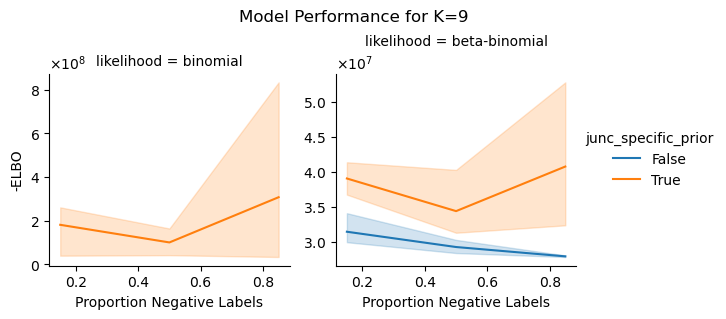

In [22]:
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(run_summary_K9, 
                  col="likelihood",
                  hue="junc_specific_prior",
                  sharey=False)

# Use line plot to show trends more clearly
g.map(sns.lineplot, "proportion_negative", "best_elbo")

# Format y-axis labels
for ax in g.axes.flat:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

g.add_legend()
g.set_axis_labels("Proportion Negative Labels", "-ELBO")

g.fig.suptitle('Model Performance for K=9', y=1.05)  # y=1.02 raises it slightly above the plots

Text(0.5, 1.05, 'Model Performance for K=9')

<Figure size 1200x600 with 0 Axes>

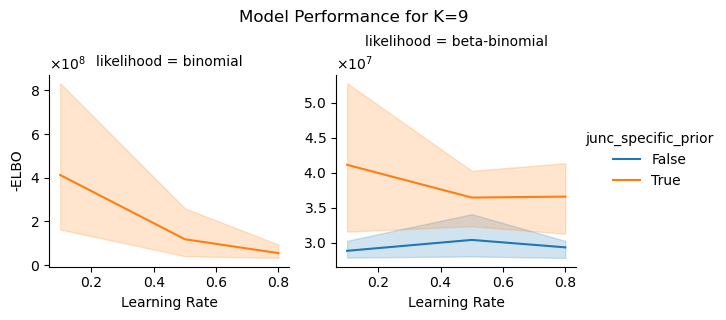

In [23]:
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(run_summary_K9, 
                  col="likelihood",
                  hue="junc_specific_prior",
                  sharey=False)

# Use line plot to show trends more clearly
g.map(sns.lineplot, "lr", "best_elbo")

# Format y-axis labels
for ax in g.axes.flat:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

g.add_legend()
g.set_axis_labels("Learning Rate", "-ELBO")

# Add title
g.fig.suptitle('Model Performance for K=9', y=1.05)  # y=1.02 raises it slightly above the plots

### Now let's summarize accuracy metrics 

In [24]:
run_summary_K2

,param_id,K,junc_specific_prior,best_elbo,input_conc,num_epochs,num_inits,cell_type_silhouette,avg_corr,median_corr,min_corr,lr,ELBO_num_particles,num_samples,proportion_negative,pruned_K,likelihood,auc_pr,auc_roc,run
0,26,2,False,2.785181e+07,1660.285200,300,5,0.930445,0.929524,0.908810,0.891891,0.8,10,500,0.85,2,beta-binomial,0.959860,0.953768,run_26
1,3,2,True,2.816058e+07,3307.481400,300,5,0.959732,0.996106,0.997262,0.992982,0.5,10,500,0.50,2,beta-binomial,0.975413,0.961824,run_3
2,23,2,False,2.703537e+07,3646.593500,300,5,0.945056,0.598753,0.998929,-0.020178,0.5,10,500,0.85,2,beta-binomial,0.566983,0.500000,run_23
3,2,2,True,3.265411e+07,75.710060,300,5,0.925959,0.786046,0.946362,0.459550,0.1,10,500,0.85,2,beta-binomial,0.812949,0.927302,run_2
4,57,2,False,2.776624e+07,inf,300,5,0.959438,0.991020,0.996391,0.978644,0.5,10,500,0.50,2,binomial,0.976136,0.962358,run_57
5,38,2,True,1.572756e+08,inf,300,5,0.808231,0.420170,0.414098,0.065374,0.1,10,500,0.85,2,binomial,0.331537,0.608371,run_38
6,19,2,False,2.873011e+07,1038.908000,300,5,0.969982,0.389366,0.081899,0.012699,0.1,10,500,0.15,2,beta-binomial,0.984393,0.936313,run_19
7,60,2,False,2.744205e+07,inf,300,5,0.965130,0.239601,0.075836,-0.018102,0.8,10,500,0.50,2,binomial,0.579911,0.633263,run_60
8,41,2,True,3.626807e+07,inf,300,5,0.885932,0.962430,0.983318,0.919441,0.5,10,500,0.85,2,binomial,0.968626,0.972373,run_41
9,22,2,False,2.835002e+07,4471.543000,300,5,0.972263,0.998756,0.999180,0.997108,0.5,10,500,0.15,2,beta-binomial,0.985821,0.940265,run_22


<Figure size 1000x600 with 0 Axes>

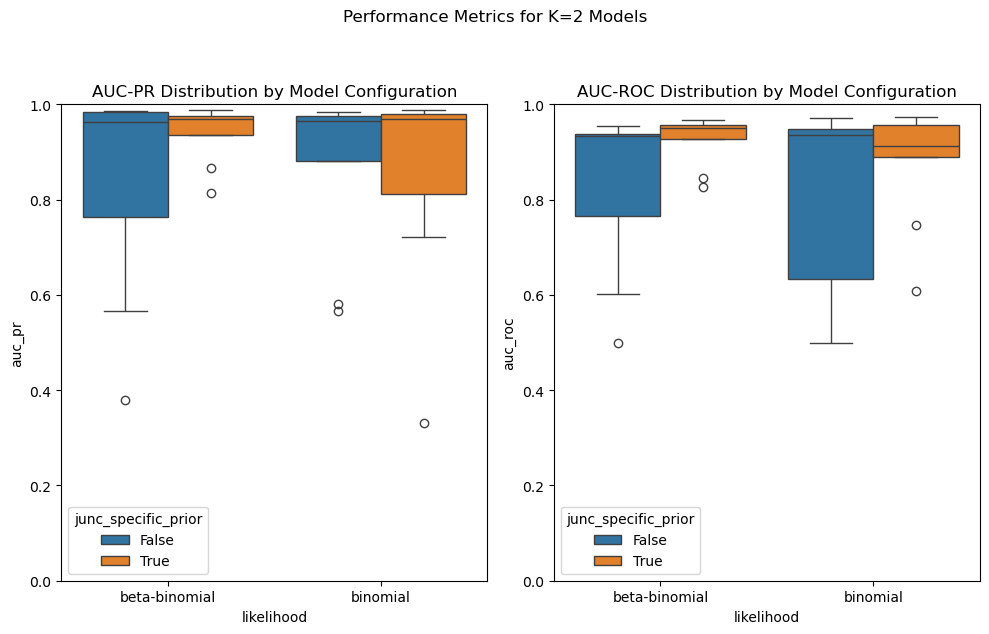

In [25]:
plt.figure(figsize=(10, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# Plot for AUC-PR
sns.boxplot(x='likelihood', y='auc_pr', 
           hue='junc_specific_prior',
           data=run_summary_K2, ax=ax1)
ax1.set_title('AUC-PR Distribution by Model Configuration')
ax1.set_ylim(0, 1)

# Plot for AUC-ROC
sns.boxplot(x='likelihood', y='auc_roc',
           hue='junc_specific_prior',
           data=run_summary_K2, ax=ax2)
ax2.set_title('AUC-ROC Distribution by Model Configuration')
ax2.set_ylim(0, 1)

plt.suptitle('Performance Metrics for K=2 Models', y=1.05)
plt.tight_layout()

<Figure size 1000x600 with 0 Axes>

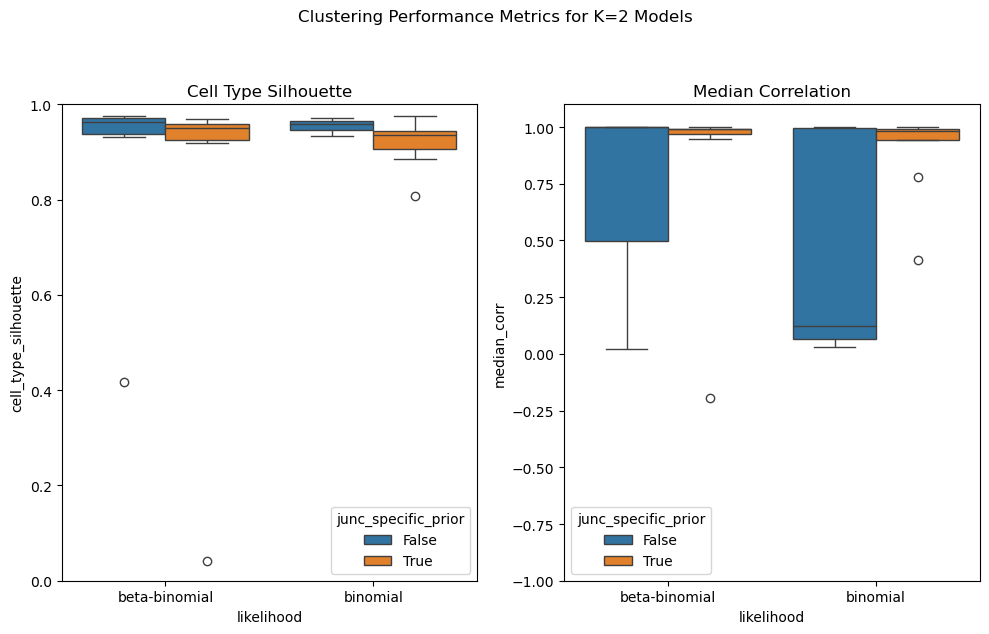

In [26]:
# Second figure for Silhouette and Correlation metrics
plt.figure(figsize=(10, 6))
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(10, 6))

# Plot for Cell Type Silhouette
sns.boxplot(x='likelihood', y='cell_type_silhouette',
            hue='junc_specific_prior',
            data=run_summary_K2, ax=ax3)
ax3.set_title('Cell Type Silhouette')
ax3.set_ylim(0, 1)

# Plot for Median Correlation
sns.boxplot(x='likelihood', y='median_corr',
            hue='junc_specific_prior',
            data=run_summary_K2, ax=ax4)
ax4.set_title('Median Correlation')
ax4.set_ylim(-1, 1.1)  # Since correlation ranges from -1 to 1

plt.suptitle('Clustering Performance Metrics for K=2 Models', y=1.05)
plt.tight_layout()